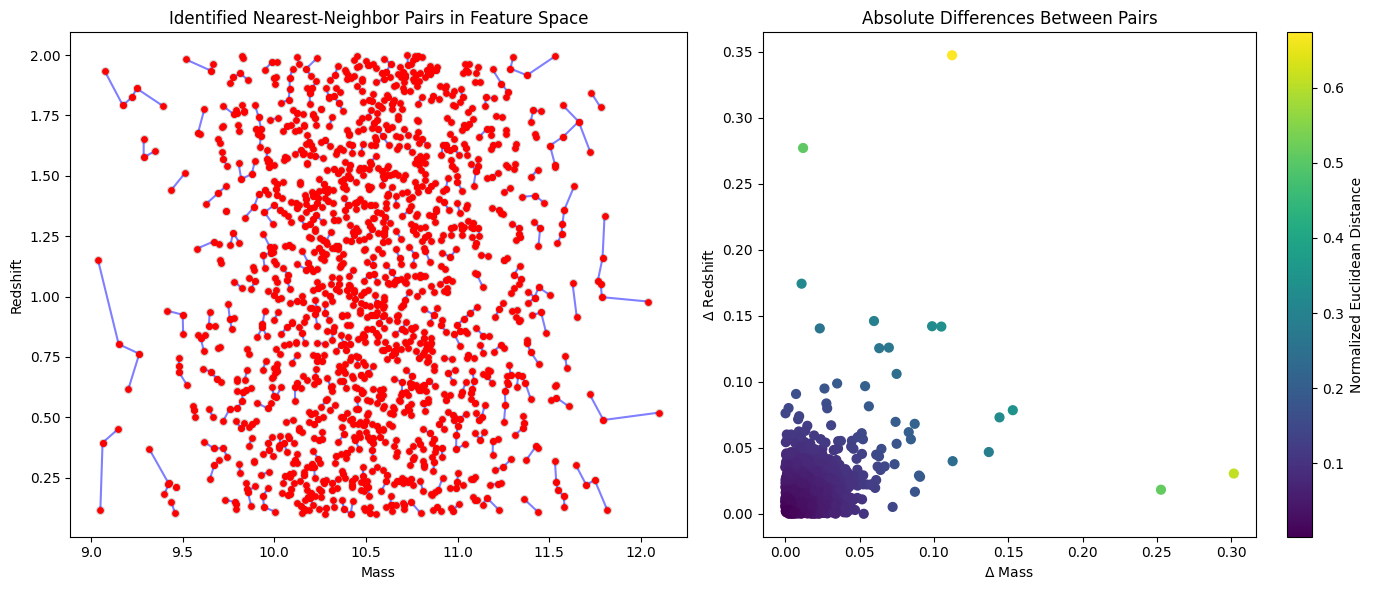

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy import spatial

# ==========================================
# 1. YOUR FUNCTIONS (Slightly cleaned up)
# ==========================================
def normalize_data(data, type='minmax'):
    data = np.array(data, dtype=float)
    if type == 'minmax':
        d_min, d_max = np.nanmin(data), np.nanmax(data)
        if d_max == d_min: return np.zeros_like(data)
        return (data - d_min) / (d_max - d_min)
    elif type == 'zscore':
        std = np.nanstd(data)
        if std == 0: return np.zeros_like(data)
        return (data - np.nanmean(data)) / std

def get_kdtree_pairs(table, pairing_keys, norm_type='zscore', n_neighbors=2, unique_pairs=True):
    points = np.stack([normalize_data(table[pk], type=norm_type) for pk in pairing_keys], axis=1)
    tree = spatial.KDTree(points)
    distances, indices = tree.query(points, k=n_neighbors)
    
    if n_neighbors < 2:
        return np.empty((0, 2), dtype=int), np.empty(0)

    n_points = len(points)
    base_indices = np.repeat(np.arange(n_points), n_neighbors - 1)
    neighbor_indices = indices[:, 1:].flatten()
    flat_distances = distances[:, 1:].flatten()
    pair_indices = np.column_stack((base_indices, neighbor_indices))
    
    if unique_pairs:
        pair_indices = np.sort(pair_indices, axis=1)
        pair_indices, unique_pairs_idxs = np.unique(pair_indices, axis=0, return_index=True)
        flat_distances = flat_distances[unique_pairs_idxs]

    return pair_indices, flat_distances

def build_generic_pairs_table(table, pair_indices):
    idx1, idx2 = pair_indices[:, 0], pair_indices[:, 1]
    pairs_dict = {"index_1": idx1, "index_2": idx2}
    for col in table.colnames:
        pairs_dict[f"{col}_1"] = table[col][idx1]
        pairs_dict[f"{col}_2"] = table[col][idx2]
    return Table(pairs_dict)

# ==========================================
# 2. GENERATE MOCK DATA
# ==========================================
# np.random.seed(42)
n_objects = 1500

# Mock catalog with 'mass' and 'redshift'
mock_data = Table({
    'object_id': np.arange(n_objects),
    'mass': np.random.normal(10.5, 0.5, n_objects),
    'redshift': np.random.uniform(0.1, 2.0, n_objects)
})

# ==========================================
# 3. RUN PAIRING LOGIC
# ==========================================
pairing_keys = ['mass', 'redshift']
pair_indices, pair_distances = get_kdtree_pairs(mock_data, pairing_keys, norm_type='zscore', n_neighbors=2)
pairs_table = build_generic_pairs_table(mock_data, pair_indices)

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Feature Space Network ---
# Plot all underlying points
ax1.scatter(mock_data['mass'], mock_data['redshift'], c='lightgrey', s=30, label='All Objects', zorder=1)

# Draw lines connecting the identified pairs
for row in pairs_table:
    x_vals = [row['mass_1'], row['mass_2']]
    y_vals = [row['redshift_1'], row['redshift_2']]
    # Plot connecting line
    ax1.plot(x_vals, y_vals, c='blue', alpha=0.5, linewidth=1.5, zorder=2)
    # Highlight paired points
    ax1.scatter(x_vals, y_vals, c='red', s=15, zorder=3)

ax1.set_title("Identified Nearest-Neighbor Pairs in Feature Space")
ax1.set_xlabel("Mass")
ax1.set_ylabel("Redshift")

# --- Plot 2: Pair Difference Distribution ---
# Calculate absolute differences between pairs for each feature
delta_mass = np.abs(pairs_table['mass_1'] - pairs_table['mass_2'])
delta_redshift = np.abs(pairs_table['redshift_1'] - pairs_table['redshift_2'])

ax2.scatter(delta_mass, delta_redshift, c=pair_distances, cmap='viridis', s=40)
ax2.set_title("Absolute Differences Between Pairs")
ax2.set_xlabel(r"$\Delta$ Mass")
ax2.set_ylabel(r"$\Delta$ Redshift")

# Add a colorbar for the normalized KD-Tree distance
cbar = plt.colorbar(ax2.collections[0], ax=ax2)
cbar.set_label("Normalized Euclidean Distance")

plt.tight_layout()
plt.show()

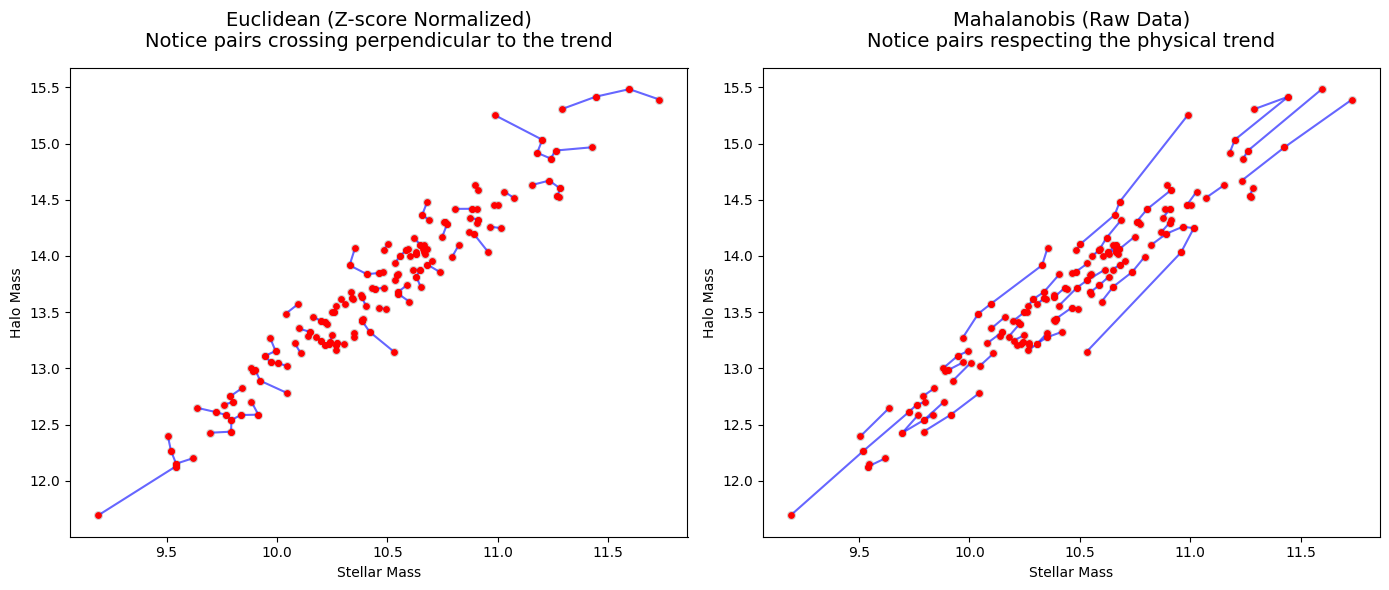

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy import spatial
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. GENERATE CORRELATED MOCK DATA
# ==========================================
np.random.seed(42)
n_objects = 150

# Create a strong correlation (e.g., Stellar Mass vs. Halo Mass)
stellar_mass = np.random.normal(10.5, 0.5, n_objects)

# Halo mass is dependent on stellar mass, plus some natural physical scatter
halo_mass = 1.5 * stellar_mass - 2.0 + np.random.normal(0, 0.2, n_objects)

mock_data = Table({
    'object_id': np.arange(n_objects),
    'stellar_mass': stellar_mass,
    'halo_mass': halo_mass
})

# ==========================================
# 2. ALGORITHM 1: EUCLIDEAN (KD-Tree)
# ==========================================
def get_euclidean_pairs(table, keys):
    # Standard Z-score normalization
    points = np.stack([ (table[k] - np.mean(table[k])) / np.std(table[k]) for k in keys ], axis=1)
    
    tree = spatial.KDTree(points)
    _, indices = tree.query(points, k=2)
    
    # Extract just the closest neighbor pairs
    pair_indices = np.column_stack((np.arange(len(points)), indices[:, 1]))
    pair_indices = np.sort(pair_indices, axis=1)
    return np.unique(pair_indices, axis=0)

# ==========================================
# 3. ALGORITHM 2: MAHALANOBIS (Scikit-Learn)
# ==========================================
def get_mahalanobis_pairs(table, keys):
    # NO normalization needed; we use the raw values
    points = np.stack([table[k] for k in keys], axis=1)
    
    # Calculate Covariance and its Inverse
    cov_matrix = np.cov(points, rowvar=False)
    inv_cov_matrix = np.linalg.inv(cov_matrix)
    
    # Fit NearestNeighbors with the custom metric
    nn = NearestNeighbors(n_neighbors=2, algorithm='brute', 
                          metric='mahalanobis', metric_params={'VI': inv_cov_matrix})
    nn.fit(points)
    _, indices = nn.kneighbors(points)
    
    # Extract pairs
    pair_indices = np.column_stack((np.arange(len(points)), indices[:, 1]))
    pair_indices = np.sort(pair_indices, axis=1)
    return np.unique(pair_indices, axis=0)

# ==========================================
# 4. RUN AND VISUALIZE
# ==========================================
keys = ['stellar_mass', 'halo_mass']
euclidean_pairs = get_euclidean_pairs(mock_data, keys)
mahalanobis_pairs = get_mahalanobis_pairs(mock_data, keys)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_pairs(ax, table, pairs, title):
    # Plot background points
    ax.scatter(table['stellar_mass'], table['halo_mass'], c='lightgrey', s=30, zorder=1)
    
    # Draw connections
    for row in pairs:
        idx1, idx2 = row[0], row[1]
        x_vals = [table['stellar_mass'][idx1], table['stellar_mass'][idx2]]
        y_vals = [table['halo_mass'][idx1], table['halo_mass'][idx2]]
        
        ax.plot(x_vals, y_vals, c='blue', alpha=0.6, linewidth=1.5, zorder=2)
        ax.scatter(x_vals, y_vals, c='red', s=15, zorder=3)
        
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Stellar Mass")
    ax.set_ylabel("Halo Mass")
    # Keep aspect ratio roughly equivalent to show true geometric bias
    ax.set_aspect('auto', adjustable='datalim') 

plot_pairs(ax1, mock_data, euclidean_pairs, "Euclidean (Z-score Normalized)\nNotice pairs crossing perpendicular to the trend")
plot_pairs(ax2, mock_data, mahalanobis_pairs, "Mahalanobis (Raw Data)\nNotice pairs respecting the physical trend")

plt.tight_layout()
plt.show()

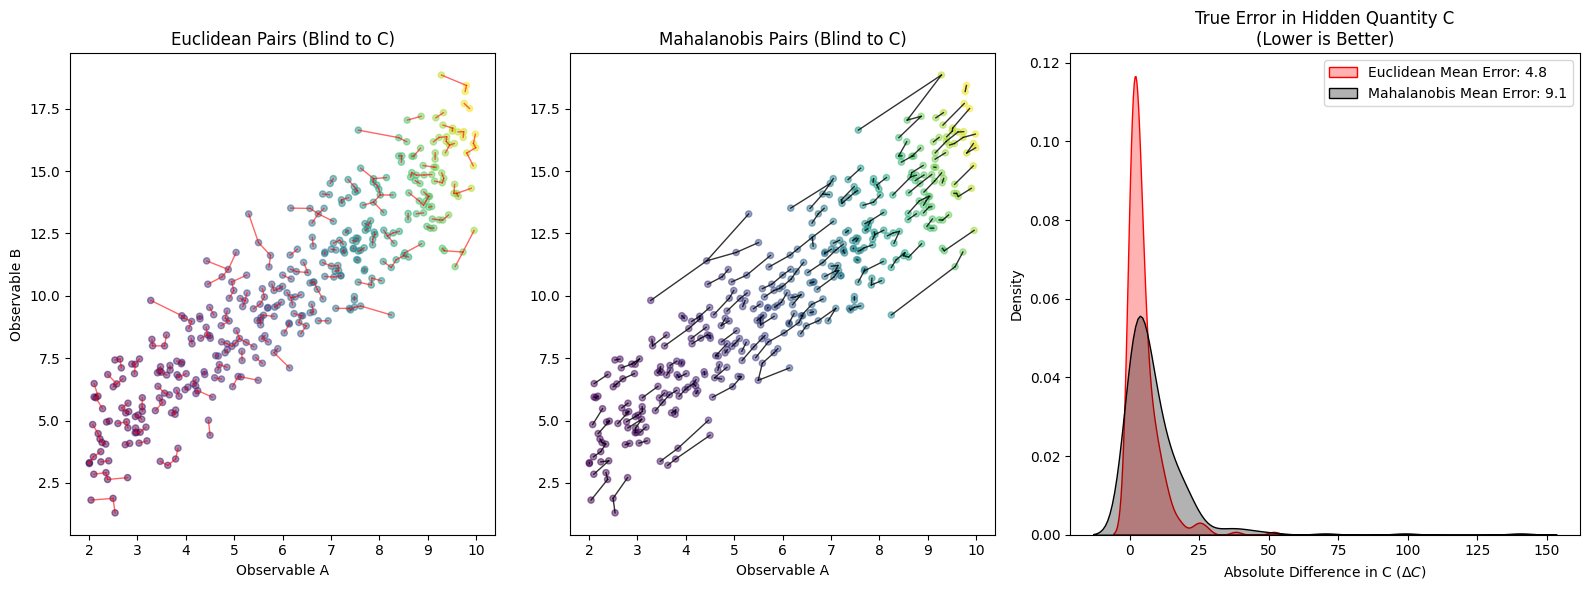

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial
from sklearn.neighbors import NearestNeighbors
import seaborn as sns

# ==========================================
# 1. GENERATE OBSERVABLE AND HIDDEN DATA
# ==========================================
np.random.seed(101)
n_objects = 400

# Observable A (e.g., Log Radius)
A = np.random.uniform(2, 10, n_objects)

# Observable B (e.g., Log Mass) - Correlated with A
B = 1.5 * A + np.random.normal(0, 1.5, n_objects)
# Ensure B stays positive for our math below
B = np.abs(B) + 1 

# HIDDEN QUANTITY C (e.g., Binding Energy, Dynamical Mass)
# C depends heavily on the non-linear combination of A and B
C = (A**2) * np.sqrt(B)

points_AB = np.column_stack((A, B))

# ==========================================
# 2. PAIRING ALGORITHMS (BLIND TO C)
# ==========================================

# -- Euclidean (Z-Score) --
A_z = (A - np.mean(A)) / np.std(A)
B_z = (B - np.mean(B)) / np.std(B)
points_z = np.column_stack((A_z, B_z))

tree = spatial.KDTree(points_z)
_, idx_euc = tree.query(points_z, k=2)
pairs_euc = np.unique(np.sort(np.column_stack((np.arange(n_objects), idx_euc[:, 1])), axis=1), axis=0)

# -- Mahalanobis --
cov = np.cov(points_AB, rowvar=False)
inv_cov = np.linalg.inv(cov)

nn = NearestNeighbors(n_neighbors=2, algorithm='brute', metric='mahalanobis', metric_params={'VI': inv_cov})
nn.fit(points_AB)
_, idx_mah = nn.kneighbors(points_AB)
pairs_mah = np.unique(np.sort(np.column_stack((np.arange(n_objects), idx_mah[:, 1])), axis=1), axis=0)

# ==========================================
# 3. EVALUATE THE TRUTH (DELTA C)
# ==========================================
# How different is the hidden quantity C between our pairs?
delta_C_euc = np.abs(C[pairs_euc[:, 0]] - C[pairs_euc[:, 1]])
delta_C_mah = np.abs(C[pairs_mah[:, 0]] - C[pairs_mah[:, 1]])

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

# Plot 1: Euclidean Pairs on the A/B Plane colored by C
ax1 = fig.add_subplot(gs[0])
scatter = ax1.scatter(A, B, c=C, cmap='viridis', s=20, alpha=0.5)
for row in pairs_euc:
    ax1.plot([A[row[0]], A[row[1]]], [B[row[0]], B[row[1]]], c='red', lw=1, alpha=0.6)
ax1.set_title("Euclidean Pairs (Blind to C)")
ax1.set_xlabel("Observable A")
ax1.set_ylabel("Observable B")

# Plot 2: Mahalanobis Pairs on the A/B Plane colored by C
ax2 = fig.add_subplot(gs[1])
ax2.scatter(A, B, c=C, cmap='viridis', s=20, alpha=0.5)
for row in pairs_mah:
    ax2.plot([A[row[0]], A[row[1]]], [B[row[0]], B[row[1]]], c='black', lw=1, alpha=0.8)
ax2.set_title("Mahalanobis Pairs (Blind to C)")
ax2.set_xlabel("Observable A")

# Plot 3: Distribution of the Error in C
ax3 = fig.add_subplot(gs[2])
sns.kdeplot(delta_C_euc, ax=ax3, color='red', fill=True, alpha=0.3, label=f'Euclidean Mean Error: {np.mean(delta_C_euc):.1f}')
sns.kdeplot(delta_C_mah, ax=ax3, color='black', fill=True, alpha=0.3, label=f'Mahalanobis Mean Error: {np.mean(delta_C_mah):.1f}')
ax3.set_title("True Error in Hidden Quantity C\n(Lower is Better)")
ax3.set_xlabel(r"Absolute Difference in C ($\Delta C$)")
ax3.set_ylabel("Density")
ax3.legend()

plt.tight_layout()
plt.show()

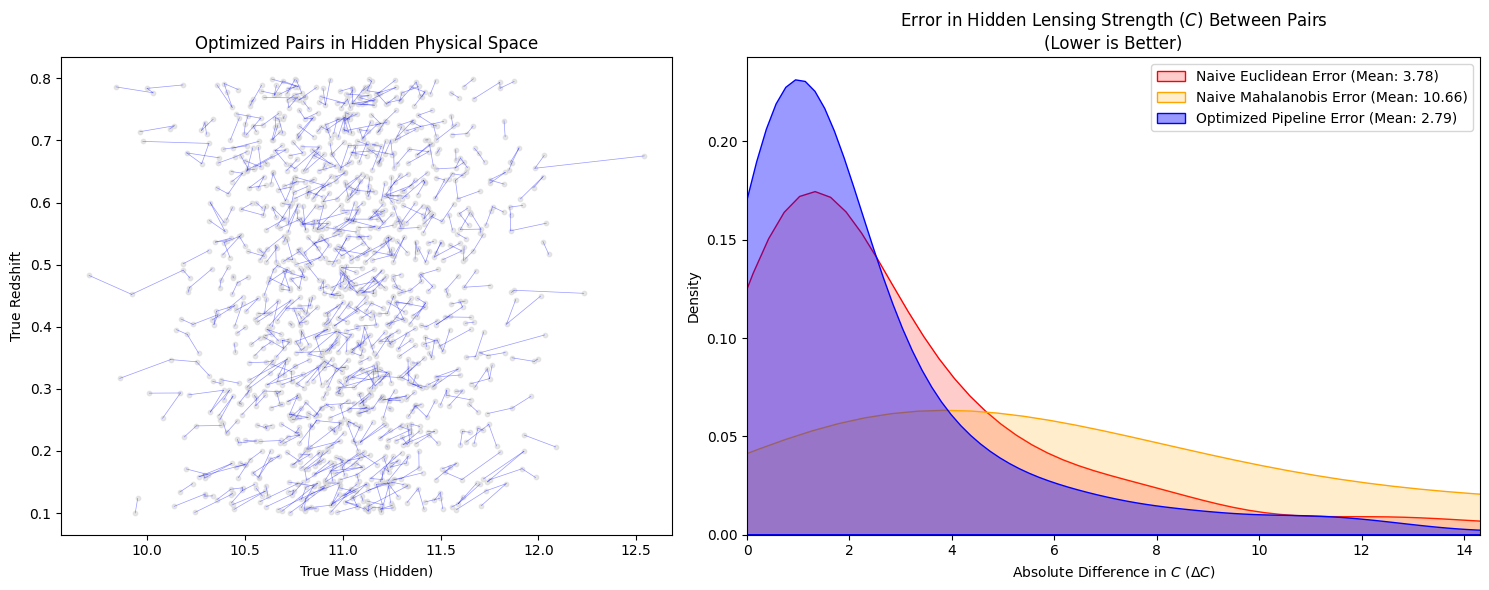

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.table import Table
from scipy import spatial
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. GENERATE MOCK PHOTOMETRIC LENS CATALOG
# ==========================================
np.random.seed(42)
n_gals = 1500

# True physical parameters (HIDDEN from algorithms)
true_mass = np.random.normal(11.0, 0.4, n_gals)
redshift = np.random.uniform(0.1, 0.8, n_gals)

# HIDDEN TARGET VARIABLE C (Lensing Strength proxy)
# Depends non-linearly on true mass and redshift
C_hidden = (true_mass ** 1.5) / (redshift + 0.1)

# Observables (WHAT THE ALGORITHMS SEE)
size_reff = 0.5 * true_mass - 3.0 + np.random.normal(0, 0.15, n_gals)
mag_r = -2.5 * true_mass + 5 * np.log10(redshift + 0.1) + 45 + np.random.normal(0, 0.1, n_gals)
mag_g = mag_r + 1.2 + np.random.normal(0, 0.05, n_gals)
mag_i = mag_r - 0.4 + np.random.normal(0, 0.05, n_gals)
mag_z = mag_i - 0.3 + np.random.normal(0, 0.05, n_gals)

cat = Table({
    'id': np.arange(n_gals),
    'z': redshift, 'reff': size_reff,
    'g': mag_g, 'r': mag_r, 'i': mag_i, 'z_mag': mag_z
})

features_all = ['z', 'reff', 'g', 'r', 'i', 'z_mag']

# Helper to extract unique pairs from a neighbor query
def extract_unique_pairs(indices, base_ids=None):
    if base_ids is None: base_ids = np.arange(len(indices))
    pair_matrix = np.sort(np.column_stack((base_ids, indices[:, 1])), axis=1)
    return np.unique(pair_matrix, axis=0)

# ==========================================
# 2. NAIVE EUCLIDEAN (Z-Score)
# ==========================================
X_euc = np.column_stack([(cat[col] - np.mean(cat[col])) / np.std(cat[col]) for col in features_all])
tree_euc = spatial.KDTree(X_euc)
_, idx_euc = tree_euc.query(X_euc, k=2)
pairs_euc = extract_unique_pairs(idx_euc)

# ==========================================
# 3. NAIVE MAHALANOBIS (Raw Data)
# ==========================================
X_mah = np.column_stack([cat[col] for col in features_all])
cov = np.cov(X_mah, rowvar=False)
inv_cov = np.linalg.inv(cov)
nn_mah = NearestNeighbors(n_neighbors=2, algorithm='brute', metric='mahalanobis', metric_params={'VI': inv_cov})
nn_mah.fit(X_mah)
_, idx_mah = nn_mah.kneighbors(X_mah)
pairs_mah = extract_unique_pairs(idx_mah)

# ==========================================
# 4. OPTIMIZED PIPELINE (Binned + PCA + Weighted)
# ==========================================
def get_optimized_pairs(catalog, z_bin_width=0.05):
    all_pairs = []
    photo_cols = ['g', 'r', 'i', 'z_mag']
    
    z_bins = np.arange(catalog['z'].min(), catalog['z'].max() + z_bin_width, z_bin_width)
    
    for i in range(len(z_bins) - 1):
        mask = (catalog['z'] >= z_bins[i]) & (catalog['z'] < z_bins[i+1])
        bin_cat = catalog[mask]
        
        if len(bin_cat) < 2: continue
            
        # PCA on photometry
        X_photo = np.column_stack([bin_cat[col] for col in photo_cols])
        X_scaled = StandardScaler().fit_transform(X_photo)
        X_pca = PCA(n_components=2).fit_transform(X_scaled)
        
        # Weighted Euclidean feature space
        W_mass = 3.0  # PC1 (Mass proxy) is critical for lensing C
        W_size = 1.0  # Reff matters
        W_z    = 5.0  # Exact z match within the bin is still preferred
        
        features = np.column_stack((
            bin_cat['z'] * W_z,
            X_pca[:, 0] * W_mass,  # PC1
            bin_cat['reff'] * W_size
        ))
        
        tree = spatial.KDTree(features)
        _, idx = tree.query(features, k=2)
        
        # Map local bin IDs back to global catalog IDs
        global_base = bin_cat['id']
        global_neighbor = bin_cat['id'][idx[:, 1]]
        
        pair_matrix = np.sort(np.column_stack((global_base, global_neighbor)), axis=1)
        all_pairs.append(np.unique(pair_matrix, axis=0))
        
    return np.vstack(all_pairs)

pairs_opt = get_optimized_pairs(cat, z_bin_width=0.05)

# ==========================================
# 5. EVALUATE THE TRUTH (Delta C)
# ==========================================
delta_C_euc = np.abs(C_hidden[pairs_euc[:, 0]] - C_hidden[pairs_euc[:, 1]])
delta_C_mah = np.abs(C_hidden[pairs_mah[:, 0]] - C_hidden[pairs_mah[:, 1]])
delta_C_opt = np.abs(C_hidden[pairs_opt[:, 0]] - C_hidden[pairs_opt[:, 1]])

# ==========================================
# 6. VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

# Plot 1: Show the Optimized Pairs in Physical Space
ax1 = fig.add_subplot(gs[0])
ax1.scatter(true_mass, redshift, c='lightgrey', s=10, alpha=0.5, label='Catalog')
for row in pairs_opt:
    ax1.plot([true_mass[row[0]], true_mass[row[1]]], 
             [redshift[row[0]], redshift[row[1]]], c='blue', lw=0.5, alpha=0.4)
ax1.set_title("Optimized Pairs in Hidden Physical Space")
ax1.set_xlabel("True Mass (Hidden)")
ax1.set_ylabel("True Redshift")

# Plot 2: Distribution of Errors in C
ax2 = fig.add_subplot(gs[1])
sns.kdeplot(delta_C_euc, ax=ax2, color='red', fill=True, alpha=0.2, 
            label=f'Naive Euclidean Error (Mean: {np.mean(delta_C_euc):.2f})')
sns.kdeplot(delta_C_mah, ax=ax2, color='orange', fill=True, alpha=0.2, 
            label=f'Naive Mahalanobis Error (Mean: {np.mean(delta_C_mah):.2f})')
sns.kdeplot(delta_C_opt, ax=ax2, color='blue', fill=True, alpha=0.4, 
            label=f'Optimized Pipeline Error (Mean: {np.mean(delta_C_opt):.2f})')

ax2.set_title("Error in Hidden Lensing Strength ($C$) Between Pairs\n(Lower is Better)")
ax2.set_xlabel(r"Absolute Difference in $C$ ($\Delta C$)")
ax2.set_ylabel("Density")
ax2.set_xlim(0, np.percentile(delta_C_euc, 95)) # Cut off extreme tails for readability
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open("../../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

lssty10_table = pdspl_samples['lsst_y10']['table']

pairing_keys = pdspl_samples['lsst_y10']['pairing_keys']

In [17]:
pdspl_samples['lsst_y10']['pairing_keys']

['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri']

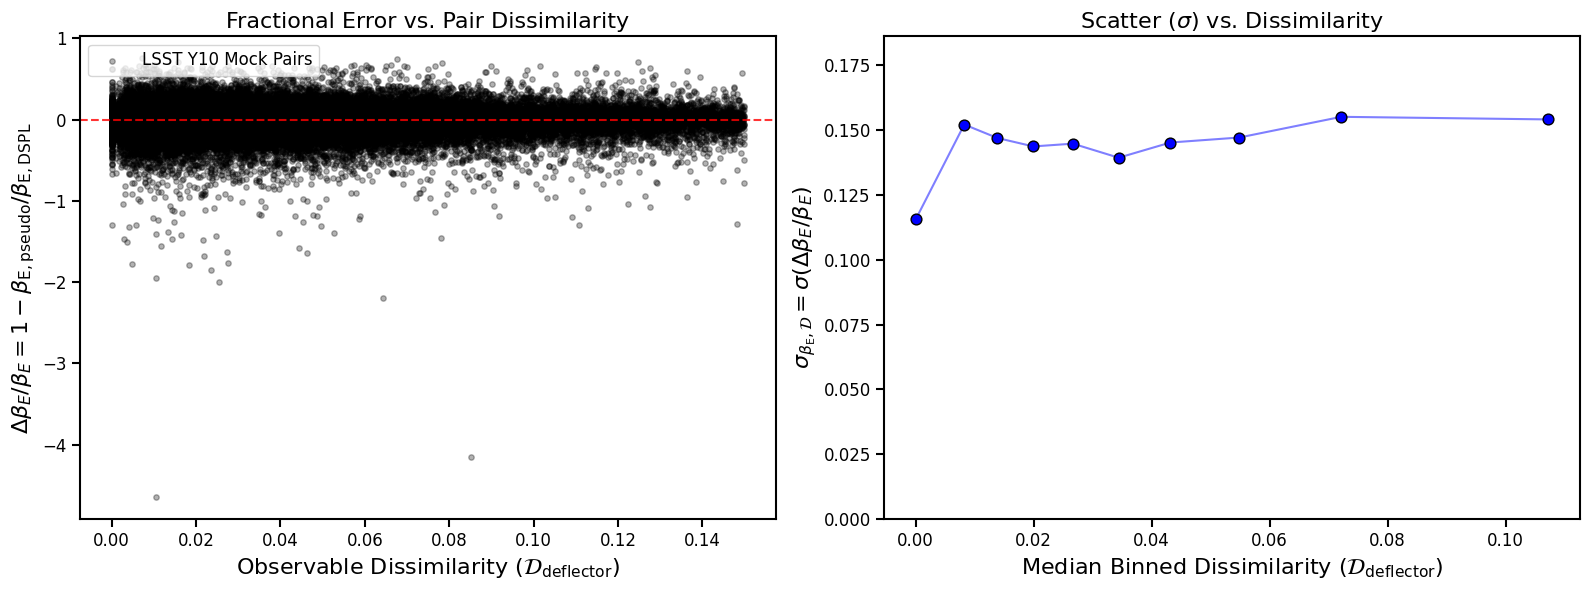

In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import spatial
from astropy.cosmology import FlatLambdaCDM

# ====================================================================
# 1. IMPORTS & DATA LOADING
# ====================================================================
# Import your exact PDSPL utilities
from pdspl_utils.pairing import get_pairs_table_PDSPL, compute_dissimilarity

# Load the real dataset
with open("../../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

lssty10_table = pdspl_samples['lsst_y10']['table']

# Standard cosmology needed for the PDSPL beta calculations
cosmo = FlatLambdaCDM(H0=70, Om0=0.3) 

# ====================================================================
# 2. THE OPTIMIZED PAIRING ALGORITHM
# ====================================================================
def get_optimized_pairs(table, z_bin_width=0.05, n_neighbors=2):
    """
    Finds physical deflector twins using Redshift Binning + PCA + Weighted Euclidean.
    Returns pair_indices, flat_distances (matching your original API).
    """
    photo_cols = ['mag_D_g', 'mag_D_r', 'mag_D_i', 'mag_D_z', 'mag_D_y']
    all_pairs = []
    
    # -------------------------------------------------------------
    # PHYSICAL WEIGHTS: Tune these based on what matters for lensing!
    # -------------------------------------------------------------
    W_z = 10.0      # Critical: Force near-exact z_D matches within the bin
    W_mass = 3.0    # PC1 (Overall Mass/Luminosity proxy)
    W_size = 2.0    # R_e_arcsec (Deflector size)
    W_color = 0.5   # PC2 (Color proxy - less critical for pure mass profile)

    # Hard Redshift Binning
    z_min, z_max = np.nanmin(table['z_D']), np.nanmax(table['z_D'])
    z_bins = np.arange(z_min, z_max + z_bin_width, z_bin_width)
    
    for i in range(len(z_bins) - 1):
        mask = (table['z_D'] >= z_bins[i]) & (table['z_D'] < z_bins[i+1])
        bin_idxs = np.where(mask)[0] # Keep track of global row indices
        bin_cat = table[mask]
        
        if len(bin_cat) < n_neighbors:
            continue
            
        # PCA Compression on Photometry to prevent "double counting" mass
        X_photo = np.column_stack([bin_cat[col] for col in photo_cols])
        # Impute any missing magnitudes with the median of the bin to prevent PCA crashing
        X_photo = np.where(np.isnan(X_photo), np.nanmedian(X_photo, axis=0), X_photo)
        
        X_scaled = StandardScaler().fit_transform(X_photo)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        # Construct Weighted Feature Space
        features = np.column_stack((
            bin_cat['z_D'] * W_z,
            X_pca[:, 0] * W_mass,     # PC1 (Mass)
            bin_cat['R_e_arcsec'] * W_size,
            X_pca[:, 1] * W_color     # PC2 (Color)
        ))
        
        # KDTree Search within this specific redshift bin
        tree = spatial.KDTree(features)
        distances, indices = tree.query(features, k=n_neighbors)
        
        # Format pairs and extract dummy distances to match old API
        n_points = len(features)
        base_indices = np.repeat(np.arange(n_points), n_neighbors - 1)
        neighbor_indices = indices[:, 1:].flatten()
        flat_distances = distances[:, 1:].flatten()
        
        # Map local bin indices back to global table indices
        global_base = bin_idxs[base_indices]
        global_neighbor = bin_idxs[neighbor_indices]
        
        pair_matrix = np.column_stack((global_base, global_neighbor))
        
        # Sort and unique
        pair_matrix = np.sort(pair_matrix, axis=1)
        pair_matrix, unique_idx = np.unique(pair_matrix, axis=0, return_index=True)
        
        all_pairs.append(pair_matrix)

    final_pairs = np.vstack(all_pairs)
    return final_pairs, np.zeros(len(final_pairs)) 

# ====================================================================
# 3. EXECUTE PIPELINE & CALCULATE METRICS
# ====================================================================

# 1. Find pairs using the optimized algorithm
pair_indices, _ = get_optimized_pairs(lssty10_table, z_bin_width=0.05, n_neighbors=2)

# 2. Feed pairs into your native PDSPL table generator
pairs_table = get_pairs_table_PDSPL(lssty10_table, pair_indices, cosmo)

# 3. Calculate Dissimilarity (D) using the observables we paired on
dissim_keys = ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_mag_D_i']
dissimilarity = compute_dissimilarity(pairs_table, dissim_keys, method='rms')

# Extract the fractional error in Beta_E (which get_pairs_table_PDSPL pre-calculates)
delta_beta = pairs_table['rel_diff_beta_E']

# ====================================================================
# 4. VISUALIZATION
# ====================================================================

# Clean out NaNs and extreme outliers for plotting
mask = np.isfinite(dissimilarity) & np.isfinite(delta_beta) & (dissimilarity < 0.15)
D_clean = dissimilarity[mask]
delta_clean = delta_beta[mask]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Panel: Individual Pair Scatter ---
ax1.scatter(D_clean, delta_clean, c='black', alpha=0.3, s=15, label='LSST Y10 Mock Pairs')
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax1.set_title("Fractional Error vs. Pair Dissimilarity", fontsize=16)
ax1.set_xlabel(r"Observable Dissimilarity ($\mathcal{D}_{\rm deflector}$)", fontsize=16)
ax1.set_ylabel(r"$\Delta \beta_E / \beta_E = 1 - \beta_{\rm E, pseudo}/\beta_{\rm E, DSPL}$", fontsize=16)
ax1.legend(loc='upper left', fontsize=12)

# --- Right Panel: Binned Standard Deviation (Scatter in Beta_E) ---
# Create bins for Dissimilarity
percentiles = np.percentile(D_clean, np.arange(0, 101, 10))
digitized = np.digitize(D_clean, percentiles)

binned_x, binned_std = [], []

for i in range(1, len(percentiles)):
    bin_mask = (digitized == i)
    if np.sum(bin_mask) > 5:  # Need enough points to calculate a meaningful STD
        binned_x.append(np.median(D_clean[bin_mask]))
        binned_std.append(np.nanstd(delta_clean[bin_mask]))

ax2.scatter(binned_x, binned_std, color='blue', s=60, edgecolor='k', zorder=3)
ax2.plot(binned_x, binned_std, color='blue', linestyle='-', alpha=0.5, zorder=2)

ax2.set_title("Scatter ($\\sigma$) vs. Dissimilarity", fontsize=16)
ax2.set_xlabel(r"Median Binned Dissimilarity ($\mathcal{D}_{\rm deflector}$)", fontsize=16)
ax2.set_ylabel(r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}} = \sigma(\Delta \beta_E / \beta_E)$", fontsize=16)
ax2.set_ylim(0, np.max(binned_std) * 1.2)

# Aesthetic formatting to match your corner plots
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', width=1.5, length=6, labelsize=12)

plt.tight_layout()
plt.show()

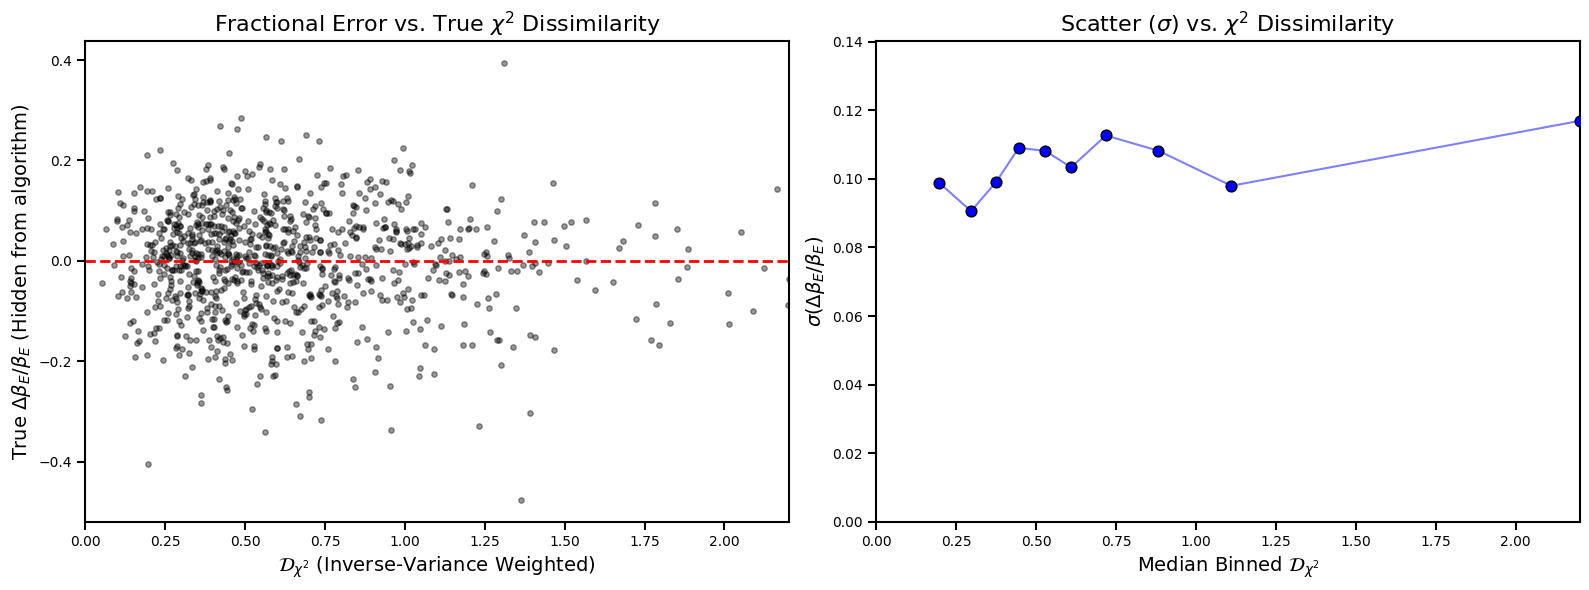

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# ====================================================================
# 1. FORWARD MODELING: MOCK DATA & ERROR INJECTION
# ====================================================================
def generate_realistic_mock(n_gals=1500):
    np.random.seed(42)
    
    # 1. TRUE Physical Properties (Hidden from the algorithm)
    true_mass = np.random.normal(11.0, 0.4, n_gals)
    true_z = np.random.uniform(0.1, 0.8, n_gals)
    true_R = 0.5 * true_mass - 3.0 + np.random.normal(0, 0.1, n_gals)
    true_mag_i = -2.5 * true_mass + 5 * np.log10(true_z + 0.1) + 45
    
    # Target Lensing Proxy (beta_E proxy)
    true_beta_E = (true_mass ** 1.5) / (true_z + 0.1)
    
    # 2. INJECT OBSERVATIONAL ERRORS (LSST-like)
    # Photo-z error scales with redshift
    err_z_obs = 0.03 * (1 + true_z)
    obs_z = true_z + np.random.normal(0, err_z_obs)
    
    # Size error (~5-10% depending on size)
    err_R_obs = 0.05 * true_R + 0.02
    obs_R = true_R + np.random.normal(0, err_R_obs)
    
    # Magnitude error (signal-to-noise dependent, normally ~0.02)
    err_mag_obs = np.random.uniform(0.01, 0.05, n_gals)
    obs_mag_i = true_mag_i + np.random.normal(0, err_mag_obs)
    
    return Table({
        'id': np.arange(n_gals),
        'true_beta_E': true_beta_E,
        'obs_z_D': obs_z,          'err_z_D': err_z_obs,
        'obs_R_e': obs_R,          'err_R_e': err_R_obs,
        'obs_mag_i': obs_mag_i,    'err_mag_i': err_mag_obs
    })

catalog = generate_realistic_mock()

# ====================================================================
# 2. THE UNIFIED DATA-DRIVEN PAIRING ALGORITHM (Chi-Square)
# ====================================================================
def get_chi2_pairs(table, feature_tuples, z_bin_width=0.05):
    """
    Pairs galaxies based on Inverse Variance Weighting (Chi-Square).
    feature_tuples: list of ('observable_col', 'error_col')
    """
    all_pairs = []
    dissimilarity_scores = []
    
    z_min, z_max = np.nanmin(table['obs_z_D']), np.nanmax(table['obs_z_D'])
    z_bins = np.arange(z_min, z_max + z_bin_width, z_bin_width)
    
    for i in range(len(z_bins) - 1):
        mask = (table['obs_z_D'] >= z_bins[i]) & (table['obs_z_D'] < z_bins[i+1])
        bin_idxs = np.where(mask)[0]
        bin_cat = table[mask]
        
        n_in_bin = len(bin_cat)
        if n_in_bin < 2: continue
            
        # Extract features (X) and their errors (E)
        X = np.column_stack([bin_cat[obs] for obs, err in feature_tuples])
        E = np.column_stack([bin_cat[err] for obs, err in feature_tuples])
        
        # Calculate full pairwise Chi-Square Distance Matrix for this bin
        # D_ij^2 = sum_k [ (X_ik - X_jk)^2 / (E_ik^2 + E_jk^2) ]
        n_features = X.shape[1]
        dist_matrix = np.zeros((n_in_bin, n_in_bin))
        
        for k in range(n_features):
            # Broadcasting to get pairwise differences and combined variances
            diff_sq = (X[:, k][:, np.newaxis] - X[:, k]) ** 2
            var_sum = (E[:, k][:, np.newaxis] ** 2) + (E[:, k] ** 2)
            dist_matrix += diff_sq / var_sum
            
        # Final Dissimilarity D (normalized by number of features)
        dist_matrix = np.sqrt(dist_matrix / n_features)
        
        # Prevent pairing with self
        np.fill_diagonal(dist_matrix, np.inf)
        
        # Find the single nearest neighbor for each galaxy
        nearest_neighbors = np.argmin(dist_matrix, axis=1)
        nearest_distances = np.min(dist_matrix, axis=1)
        
        # Map local back to global IDs
        global_base = bin_idxs
        global_neighbor = bin_idxs[nearest_neighbors]
        
        pair_matrix = np.column_stack((global_base, global_neighbor))
        
        # Deduplicate pairs (A pairs with B -> B pairs with A)
        pair_matrix = np.sort(pair_matrix, axis=1)
        unique_pairs, unique_idx = np.unique(pair_matrix, axis=0, return_index=True)
        unique_distances = nearest_distances[unique_idx]
        
        all_pairs.append(unique_pairs)
        dissimilarity_scores.append(unique_distances)
        
    return np.vstack(all_pairs), np.concatenate(dissimilarity_scores)

# Define the features and their corresponding error columns
features_to_match = [
    ('obs_z_D', 'err_z_D'),
    ('obs_R_e', 'err_R_e'),
    ('obs_mag_i', 'err_mag_i')
]

# Run the Pairing!
pair_indices, pair_dissimilarities = get_chi2_pairs(catalog, features_to_match, z_bin_width=0.05)

# ====================================================================
# 3. EVALUATION: TRUTH VS. DISSIMILARITY
# ====================================================================

# Calculate True Error in Beta_E (Since we have the hidden truth in this mock)
idx1, idx2 = pair_indices[:, 0], pair_indices[:, 1]
beta_1 = catalog['true_beta_E'][idx1]
beta_2 = catalog['true_beta_E'][idx2]

delta_beta_E = 1 - (beta_1 / beta_2)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Panel: Scatter ---
ax1.scatter(pair_dissimilarities, delta_beta_E, c='black', alpha=0.4, s=15)
ax1.axhline(0, color='red', linestyle='--', lw=2)
ax1.set_title(r"Fractional Error vs. True $\chi^2$ Dissimilarity", fontsize=16)
ax1.set_xlabel(r"$\mathcal{D}_{\chi^2}$ (Inverse-Variance Weighted)", fontsize=14)
ax1.set_ylabel(r"True $\Delta \beta_E / \beta_E$ (Hidden from algorithm)", fontsize=14)
ax1.set_xlim(0, np.percentile(pair_dissimilarities, 95))

# --- Right Panel: Binned Scatter ---
percentiles = np.percentile(pair_dissimilarities, np.arange(0, 101, 10))
digitized = np.digitize(pair_dissimilarities, percentiles)

binned_x, binned_std = [], []
for i in range(1, len(percentiles)):
    mask = (digitized == i)
    if np.sum(mask) > 5:
        binned_x.append(np.median(pair_dissimilarities[mask]))
        binned_std.append(np.nanstd(delta_beta_E[mask]))

ax2.scatter(binned_x, binned_std, color='blue', s=60, edgecolor='k', zorder=3)
ax2.plot(binned_x, binned_std, color='blue', linestyle='-', alpha=0.5, zorder=2)
ax2.set_title(r"Scatter ($\sigma$) vs. $\chi^2$ Dissimilarity", fontsize=16)
ax2.set_xlabel(r"Median Binned $\mathcal{D}_{\chi^2}$", fontsize=14)
ax2.set_ylabel(r"$\sigma(\Delta \beta_E / \beta_E)$", fontsize=14)
ax2.set_xlim(0, np.percentile(pair_dissimilarities, 95))
ax2.set_ylim(0, np.max(binned_std) * 1.2)

for ax in [ax1, ax2]:
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', width=1.5, length=6)

plt.tight_layout()
plt.show()

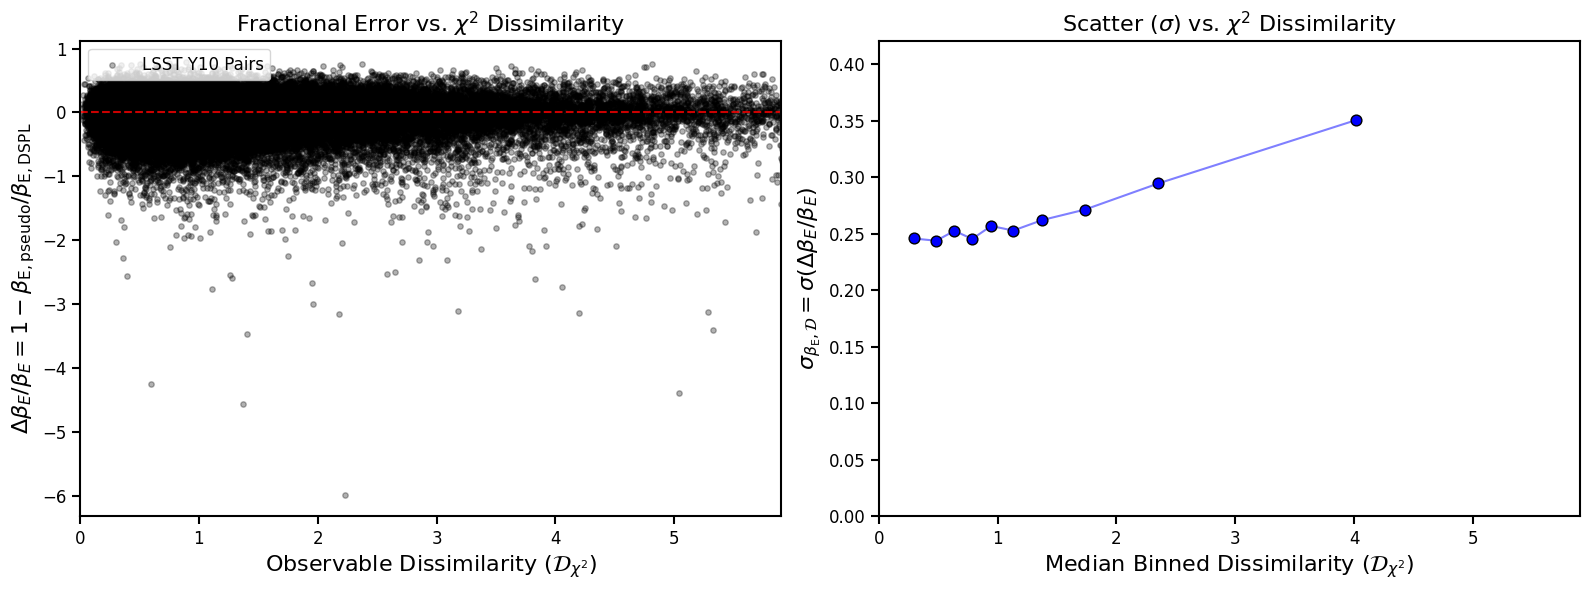

In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# ====================================================================
# 1. IMPORTS & DATA PREPARATION
# ====================================================================
from pdspl_utils.pairing import get_pairs_table_PDSPL, inject_observational_errors

# Load the real dataset
with open("../../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

raw_lssty10_table = pdspl_samples['lsst_y10']['table']
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# INJECT ERRORS: We must do this first so the Chi-Square algorithm 
# has the variance arrays (err_ columns) to calculate distances.
lssty10_table = inject_observational_errors(raw_lssty10_table, sample_key='lsst_y10')

# ====================================================================
# 2. THE CHI-SQUARE PAIRING ALGORITHM
# ====================================================================
def get_chi2_pairs(table, feature_tuples, z_bin_width=0.05):
    """
    Pairs galaxies using pure Inverse Variance Weighting.
    No arbitrary weights needed; the telescope errors dictate the matching.
    """
    all_pairs = []
    dissimilarity_scores = []
    
    z_min, z_max = np.nanmin(table['z_D']), np.nanmax(table['z_D'])
    z_bins = np.arange(z_min, z_max + z_bin_width, z_bin_width)
    
    for i in range(len(z_bins) - 1):
        mask = (table['z_D'] >= z_bins[i]) & (table['z_D'] < z_bins[i+1])
        bin_idxs = np.where(mask)[0] # Global row indices
        bin_cat = table[mask]
        
        n_in_bin = len(bin_cat)
        if n_in_bin < 2: continue
            
        # Extract features (X) and their errors (E)
        X = np.column_stack([bin_cat[obs] for obs, err in feature_tuples])
        E = np.column_stack([bin_cat[err] for obs, err in feature_tuples])
        
        n_features = X.shape[1]
        dist_matrix = np.zeros((n_in_bin, n_in_bin))
        
        # Build pairwise distance matrix
        for k in range(n_features):
            diff_sq = (X[:, k][:, np.newaxis] - X[:, k]) ** 2
            var_sum = (E[:, k][:, np.newaxis] ** 2) + (E[:, k] ** 2)
            dist_matrix += diff_sq / var_sum
            
        # Final Dissimilarity D (normalized by number of features)
        dist_matrix = np.sqrt(dist_matrix / n_features)
        
        # Prevent pairing with self
        np.fill_diagonal(dist_matrix, np.inf)
        
        # Find nearest neighbors
        nearest_neighbors = np.argmin(dist_matrix, axis=1)
        nearest_distances = np.min(dist_matrix, axis=1)
        
        # Map local IDs back to global catalog IDs
        global_base = bin_idxs
        global_neighbor = bin_idxs[nearest_neighbors]
        
        pair_matrix = np.column_stack((global_base, global_neighbor))
        
        # Deduplicate (If A pairs with B, and B pairs with A, keep one)
        pair_matrix = np.sort(pair_matrix, axis=1)
        unique_pairs, unique_idx = np.unique(pair_matrix, axis=0, return_index=True)
        unique_distances = nearest_distances[unique_idx]
        
        all_pairs.append(unique_pairs)
        dissimilarity_scores.append(unique_distances)
        
    return np.vstack(all_pairs), np.concatenate(dissimilarity_scores)

# ====================================================================
# 3. EXECUTE PIPELINE
# ====================================================================

# Define the exact columns to match on, and their corresponding error columns
features_to_match = [
    ('z_D', 'err_z_D'),
    ('R_e_arcsec', 'err_R_e_arcsec'),
    ('mag_D_i', 'err_mag_D_i')
]

# 1. Run the pairing
pair_indices, pair_dissimilarities = get_chi2_pairs(lssty10_table, features_to_match, z_bin_width=0.05)

# 2. Feed pairs into your native PDSPL table generator to get true physical differences
pairs_table = get_pairs_table_PDSPL(lssty10_table, pair_indices, cosmo)

# Extract the fractional error in Beta_E (which your function pre-calculates)
delta_beta = pairs_table['rel_diff_beta_E']

# ====================================================================
# 4. VISUALIZATION
# ====================================================================

# Clean out NaNs and extreme outliers for plotting
mask = np.isfinite(pair_dissimilarities) & np.isfinite(delta_beta)
D_clean = pair_dissimilarities[mask]
delta_clean = delta_beta[mask]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Panel: Individual Pair Scatter ---
ax1.scatter(D_clean, delta_clean, c='black', alpha=0.3, s=15, label='LSST Y10 Pairs')
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax1.set_title(r"Fractional Error vs. $\chi^2$ Dissimilarity", fontsize=16)
ax1.set_xlabel(r"Observable Dissimilarity ($\mathcal{D}_{\chi^2}$)", fontsize=16)
ax1.set_ylabel(r"$\Delta \beta_E / \beta_E = 1 - \beta_{\rm E, pseudo}/\beta_{\rm E, DSPL}$", fontsize=16)
ax1.set_xlim(0, np.percentile(D_clean, 98))
ax1.legend(loc='upper left', fontsize=12)

# --- Right Panel: Binned Standard Deviation (Scatter in Beta_E) ---
percentiles = np.percentile(D_clean, np.arange(0, 101, 10))
digitized = np.digitize(D_clean, percentiles)

binned_x, binned_std = [], []

for i in range(1, len(percentiles)):
    bin_mask = (digitized == i)
    if np.sum(bin_mask) > 5:  # Need enough points to calculate a meaningful STD
        binned_x.append(np.median(D_clean[bin_mask]))
        binned_std.append(np.nanstd(delta_clean[bin_mask]))

ax2.scatter(binned_x, binned_std, color='blue', s=60, edgecolor='k', zorder=3)
ax2.plot(binned_x, binned_std, color='blue', linestyle='-', alpha=0.5, zorder=2)

ax2.set_title(r"Scatter ($\sigma$) vs. $\chi^2$ Dissimilarity", fontsize=16)
ax2.set_xlabel(r"Median Binned Dissimilarity ($\mathcal{D}_{\chi^2}$)", fontsize=16)
ax2.set_ylabel(r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}} = \sigma(\Delta \beta_E / \beta_E)$", fontsize=16)
ax2.set_xlim(0, np.percentile(D_clean, 98))
ax2.set_ylim(0, np.max(binned_std) * 1.2)

# Aesthetic formatting to match your corner plots
for ax in [ax1, ax2]:
    for spine in ax.spines.values(): spine.set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', width=1.5, length=6, labelsize=12)

plt.tight_layout()
plt.show()